In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from scipy.special import iv
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score


In [46]:
def build_gorduza_graph(returns_window, threshold=0.7):
    """
    returns_window: (S, N) array — S days of returns for N stocks
    Node features X = the return series itself (N, S)
    Binary adjacency: connect if |correlation| > threshold
    """
    corr = np.corrcoef(returns_window.T)      # (N, N)
    np.fill_diagonal(corr, 0)
    A = (corr > threshold).astype(np.float32) # binary, not signed
    X = np.nan_to_num(returns_window.T, nan=0.0)  # (N, S) — returns as features
    return corr, A, X

def normalize_adj(A):
    """D^{-1/2} A D^{-1/2}  — paper eq. (3), no self-loops added"""
    d = A.sum(axis=1)
    d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
    return d_inv_sqrt[:, None] * A * d_inv_sqrt[None, :]


In [47]:
class GorduzeGAE(nn.Module):
    """
    Z = Ã * ReLU(Ã * X * W0) * W1    [eq. 3]
    A_hat_uv = sigmoid(z_u · z_v)     [eq. 4]
    """
    def __init__(self, feature_dim, hidden_dim=32, latent_dim=16):
        super().__init__()
        self.W0 = nn.Linear(feature_dim, hidden_dim, bias=False)
        self.W1 = nn.Linear(hidden_dim, latent_dim, bias=False)
        nn.init.xavier_uniform_(self.W0.weight)
        nn.init.xavier_uniform_(self.W1.weight)

    def encode(self, X, A_norm):
        H = F.relu(self.W0(A_norm @ X))   # Ã * X * W0 → ReLU
        return self.W1(A_norm @ H)         # Ã * H * W1

    def decode(self, Z):
        return torch.sigmoid(Z @ Z.T)      # inner product decoder

    def forward(self, X, A_norm):
        Z = self.encode(X, A_norm)
        return Z, self.decode(Z)


In [48]:
def train_on_Gt(model, optimizer, X_t, A_norm_t, A_t, n_epochs=50):
    X_t = torch.FloatTensor(X_t)
    A_norm_t = torch.FloatTensor(A_norm_t)
    A_t = torch.FloatTensor(A_t)

    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        _, A_hat = model(X_t, A_norm_t)
        # BCE loss on all edges [eq. 5]
        loss = F.binary_cross_entropy(A_hat, A_t)
        loss.backward()
        optimizer.step()


def compute_S_t1(model, X_t1, A_norm_t1, A_t1):
    """
    S_{t+1}: AUC of edge reconstruction on G_{t+1}.
    High → homogeneous (stable).  Low → heterogeneous (crash coming).
    """
    model.eval()
    with torch.no_grad():
        _, A_hat = model(torch.FloatTensor(X_t1), torch.FloatTensor(A_norm_t1))
    A_hat_np = A_hat.numpy()

    N = A_t1.shape[0]
    idx = np.triu_indices(N, k=1)          # upper triangle, no self-loops
    y_true  = A_t1[idx]
    y_score = A_hat_np[idx]

    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return 0.5
    return roc_auc_score(y_true, y_score)


def compute_per_node_scores(model, X_t1, A_norm_t1, A_t1):
    """
    Per-stock extension (not in paper — my adaptation for your eval framework).
    Row-wise BCE: how hard is it to reconstruct THIS stock's edges in t+1?
    Higher = more anomalous connections relative to what the model learned at t.
    """
    model.eval()
    with torch.no_grad():
        _, A_hat = model(torch.FloatTensor(X_t1), torch.FloatTensor(A_norm_t1))
    A_hat_np = np.clip(A_hat.numpy(), 1e-7, 1 - 1e-7)
    row_bce = -np.mean(
        A_t1 * np.log(A_hat_np) + (1 - A_t1) * np.log(1 - A_hat_np),
        axis=1
    )  # (N,) — higher = harder to reconstruct = more anomalous
    return row_bce


In [49]:
def run_gorduza(returns_df, test_dates, S=20, threshold=0.7,
                hidden_dim=32, latent_dim=16, n_epochs=50, lr=0.01):

    all_dates = sorted(returns_df.index)
    market_signals = {}   # date → scalar S_{t+1}
    stock_signals  = {}   # date → (stocks, per-node scores)

    for t in test_dates:
        loc = all_dates.index(t)
        if loc < S + 1:
            continue

        # Window at t and t+1 (shifted by 1 day)
        active = returns_df.columns[
            returns_df.iloc[loc - S : loc].notna().all(axis=0)
        ].tolist()
        if len(active) < 20:
            continue

        W_t  = returns_df[active].iloc[loc - S     : loc    ].values  # (S, N)
        W_t1 = returns_df[active].iloc[loc - S + 1 : loc + 1].values  # (S, N) shifted

        _, A_t,  X_t  = build_gorduza_graph(W_t,  threshold)
        _, A_t1, X_t1 = build_gorduza_graph(W_t1, threshold)

        if A_t.sum() == 0:
            continue

        A_norm_t  = normalize_adj(A_t)
        A_norm_t1 = normalize_adj(A_t1)

        # Fresh model trained on G_t each day
        model = GorduzeGAE(feature_dim=S, hidden_dim=hidden_dim, latent_dim=latent_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        train_on_Gt(model, optimizer, X_t, A_norm_t, A_t, n_epochs)

        market_signals[t] = compute_S_t1(model, X_t1, A_norm_t1, A_t1)
        scores = compute_per_node_scores(model, X_t1, A_norm_t1, A_t1)
        stock_signals[t] = (active, scores)

    return market_signals, stock_signals


In [50]:
from torch.optim import Adam
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# ── Prices (for evaluation) ────────────────────────────────────────────────────
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

# ── Returns (full history — rolling windows may reach before 2019) ─────────────
returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True)
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()

# ── Test period (match spectral notebook) ─────────────────────────────────────
# No separate training period: the paper trains a fresh model on G_t each day.
test_prices    = prices.loc['2019-07-01':'2024-12-31']
test_dates_all = returns.loc['2019-07-01':'2024-12-31'].index

K        = 21          # min obs / activity filter (matches spectral notebook)
S        = 20          # rolling window length for G_t (paper Section 5.3)
LOOKBACK = int(K * 1.5)  # calendar-day buffer for get_active_stocks

print(f"Test: {test_dates_all[0].date()} -> {test_dates_all[-1].date()}  ({len(test_dates_all)} days)")


Test: 2019-07-01 -> 2024-12-31  (1386 days)


In [51]:
def get_active_stocks(returns, t, lookback_days, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]
    ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    return window.columns[ok_nonzero].tolist()


def get_window(returns, t, window_size, active):
    """Last `window_size` trading-day rows for `active` stocks ending at t."""
    t = pd.to_datetime(t)
    sub = returns.loc[:t, active]
    return sub.iloc[-window_size:].values   # (window_size, N)


In [58]:
# ── Paper methodology (Section 5.3) ──────────────────────────────────────────
# For each day t: train a FRESH GAE on G_t, immediately test on G_{t+1}.
# S_{t+1} = AUC of edge-reconstruction on G_{t+1}  (market instability signal)
# Per-node scores = row-wise BCE on G_{t+1}         (our adaptation for stock eval)
#
# There is NO separate training period — a new model is fitted every day.

THRESHOLD = 0.7   # paper Section 5.1
N_EPOCHS  = 50    # paper trains to convergence; 20 is practical for daily loops
LR        = 0.01
HIDDEN    = 32
LATENT    = 16

test_results   = {}   # {date_t1: (active_t1_list, per_node_scores_array)}
market_signals = {}   # {date_t1: scalar AUC}

dates = test_dates_all

for i in tqdm(range(len(dates) - 1), desc="Rolling GAE (train G_t -> test G_{t+1})"):
    t  = dates[i]
    t1 = dates[i + 1]   # next trading day

    # ── Active stocks ─────────────────────────────────────────────────────────
    active_t  = get_active_stocks(returns, t,  lookback_days=LOOKBACK, min_obs=K)
    active_t1 = get_active_stocks(returns, t1, lookback_days=LOOKBACK, min_obs=K)
    if len(active_t) < 10 or len(active_t1) < 10:
        continue

    # ── Build G_t ─────────────────────────────────────────────────────────────
    W_t = get_window(returns, t, S, active_t)
    if np.isnan(W_t).any():
        W_t = np.nan_to_num(W_t, nan=0.0)
    _, A_t, X_t = build_gorduza_graph(W_t, threshold=THRESHOLD)
    if A_t.sum() == 0:
        continue
    A_norm_t = normalize_adj(A_t)

    # ── Build G_{t+1} ─────────────────────────────────────────────────────────
    W_t1 = get_window(returns, t1, S, active_t1)
    if np.isnan(W_t1).any():
        W_t1 = np.nan_to_num(W_t1, nan=0.0)
    _, A_t1, X_t1 = build_gorduza_graph(W_t1, threshold=THRESHOLD)
    A_norm_t1 = normalize_adj(A_t1)

    # ── Fresh model trained on G_t (paper: train & validate on G_t) ───────────
    model = GorduzeGAE(feature_dim=S, hidden_dim=HIDDEN, latent_dim=LATENT)
    optimizer = Adam(model.parameters(), lr=LR)
    train_on_Gt(model, optimizer, X_t, A_norm_t, A_t, n_epochs=N_EPOCHS)

    # ── Market signal S_{t+1}: AUC of G_{t+1} reconstruction ─────────────────
    # Restrict to common stocks so G_t model sees the same node set
    common = list(set(active_t) & set(active_t1))
    if len(common) >= 20:
        pi = [active_t.index(s) for s in common]
        ci = [active_t1.index(s) for s in common]
        market_signals[t1] = compute_S_t1(
            model,
            X_t1[ci, :],
            normalize_adj(A_t1[np.ix_(ci, ci)]),
            A_t1[np.ix_(ci, ci)]
        )

    # ── Per-node scores on G_{t+1} (our adaptation for stock-level eval) ──────
    if t1 in market_signals:
        warning = market_signals[t1]   # low AUC = high crash risk
        scores_paper = np.full(len(active_t1), warning)
        test_results[t1] = (active_t1, scores_paper)

pd.to_pickle(test_results,   'outputs/test_results_gorduza.pkl')
pd.to_pickle(test_prices,    'outputs/test_prices_gorduza.pkl')
pd.to_pickle(market_signals, 'outputs/market_signals_gorduza.pkl')
print(f"Done. {len(test_results)} test dates, {len(market_signals)} market signal dates.")


Rolling GAE (train G_t -> test G_{t+1}):   0%|          | 0/1385 [00:00<?, ?it/s]c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\archi\AppData\Local\Temp\ipykernel_32528\1676624809.py:16: RuntimeWarning: divide by zero encountered in divide
  d_inv_sqrt = np.where(d > 0, 1.0 / np.sqrt(d), 0.0)
Rolling GAE (train G_t -> test G_{t+1}):   0%|          | 1/1385 [00:00<08:00,  2.88it/s]c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\archi\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_b

Done. 1385 test dates, 1385 market signal dates.


In [59]:
def evaluate_once(test_results, prices, forward_window, crash_threshold):
    y_true, y_scores = [], []
    for t in sorted(test_results.keys()):
        if t > prices.index[-1] - pd.Timedelta(days=forward_window):
            continue
        stocks, signals = test_results[t]
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        available = [s for s in stocks if s in prices.columns]
        if not available:
            continue
        mask = [i for i, s in enumerate(stocks) if s in available]
        signals = signals[mask]
        p_t = prices.loc[t, available]
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices):
            continue
        p_future = prices.loc[prices.index[future_idx], available]
        fwd_returns = (p_future - p_t) / p_t
        crash = (fwd_returns < crash_threshold).astype(int)
        y_true.extend(crash.values)
        y_scores.extend(signals)
    if not y_true:
        return None
    y_true, y_scores = np.array(y_true), np.array(y_scores)
    auc = roc_auc_score(y_true, y_scores)
    baseline = y_true.mean()
    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()
    lift = precision / baseline if baseline > 0 else np.nan
    return auc, lift, baseline, precision


def grid_search(test_results, prices, forward_windows, crash_thresholds):
    rows = []
    for fw in forward_windows:
        for ct in crash_thresholds:
            result = evaluate_once(test_results, prices, fw, ct)
            if result:
                auc, lift, baseline, precision = result
                rows.append(dict(FW=fw, CT=ct, AUC=round(auc, 3),
                                 Lift=round(lift, 2), Baseline=round(baseline, 3),
                                 Precision=round(precision, 3)))
    return pd.DataFrame(rows)


# ── Evaluate ──────────────────────────────────────────────────────────────────
test_results_g  = pd.read_pickle('outputs/test_results_gorduza.pkl')
test_prices_g   = pd.read_pickle('outputs/test_prices_gorduza.pkl')

df_results = grid_search(
    test_results_g,
    test_prices_g,
    forward_windows=[10, 22],
    crash_thresholds=[-0.10, -0.15, -0.20, -0.30]
)
print(df_results.to_string(index=False))


 FW    CT   AUC  Lift  Baseline  Precision
 10 -0.10 0.538  1.60     0.033      0.052
 10 -0.15 0.627  2.82     0.012      0.034
 10 -0.20 0.717  4.05     0.006      0.024
 10 -0.30 0.797  4.94     0.002      0.008
 22 -0.10 0.492  1.01     0.066      0.067
 22 -0.15 0.505  1.07     0.027      0.029
 22 -0.20 0.509  1.07     0.013      0.014
 22 -0.30 0.515  0.96     0.004      0.004


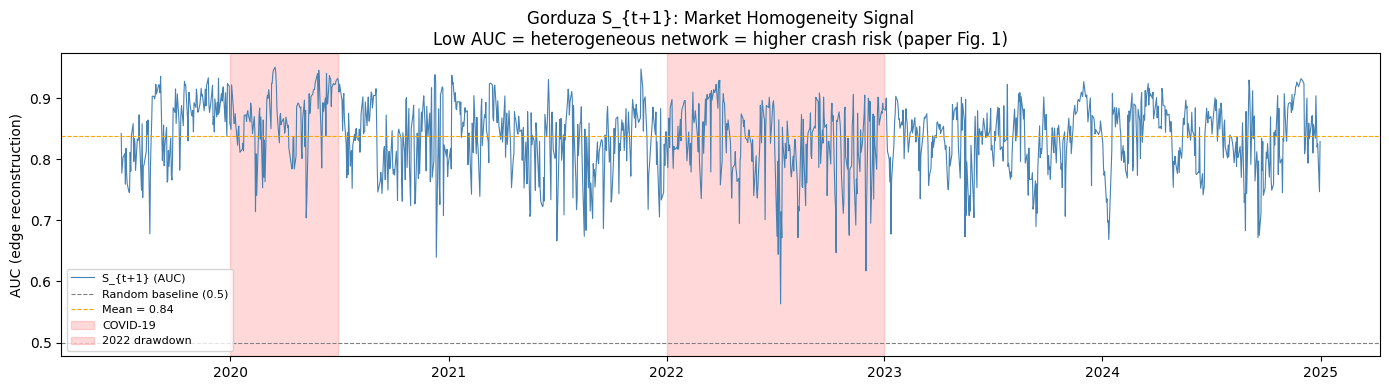

Mean S_{t+1} = 0.838  (paper reports ~0.84 on minute data)


In [60]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

market_signals = pd.read_pickle('outputs/market_signals_gorduza.pkl')

ms_dates  = sorted(market_signals.keys())
ms_values = [market_signals[d] for d in ms_dates]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ms_dates, ms_values, color='steelblue', linewidth=0.8, label='S_{t+1} (AUC)')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random baseline (0.5)')
ax.axhline(np.mean(ms_values), color='orange', linestyle='--', linewidth=0.8,
           label=f'Mean = {np.mean(ms_values):.2f}')

crashes = [('2020-01-01', '2020-06-30', 'COVID-19'),
           ('2022-01-01', '2022-12-31', '2022 drawdown')]
for start, end, label in crashes:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.15, color='red', label=label)

ax.set_title("Gorduza S_{t+1}: Market Homogeneity Signal\n"
             "Low AUC = heterogeneous network = higher crash risk (paper Fig. 1)")
ax.set_ylabel("AUC (edge reconstruction)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig('outputs/gorduza_market_signal.png', dpi=150)
plt.show()
print(f"Mean S_{{t+1}} = {np.mean(ms_values):.3f}  (paper reports ~0.84 on minute data)")
